1) Load dataset

In [1]:
import pandas as pd
import os

OUTPUT_DIR = "../outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
TAB_DIR = os.path.join(OUTPUT_DIR, "tables")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)


In [2]:
df_path = "../data/processed/feature_engineered_with_SLM.csv"
df = pd.read_csv(df_path)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             1200 non-null   int64  
 1   customer_id                1200 non-null   int64  
 2   transaction_datetime       1200 non-null   object 
 3   country                    1200 non-null   object 
 4   channel                    1200 non-null   object 
 5   merchant_category          1200 non-null   object 
 6   amount                     1200 non-null   float64
 7   device_trust_score         1200 non-null   float64
 8   num_txn_24h_customer       1200 non-null   int64  
 9   previous_chargeback_count  1200 non-null   int64  
 10  is_fraud                   1200 non-null   int64  
 11  transaction_note           1200 non-null   object 
 12  slm_risk_score             1200 non-null   int64  
 13  slm_urgency                1200 non-null   objec

In [3]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)

print(missing[missing > 0].to_frame("Count of missing values"))

                     Count of missing values
txn_7d_count                            1200
prev_txn_time                            179
amount_z_customer                          1
customer_std_amount                        1


In [4]:
df.head()

,transaction_id,customer_id,transaction_datetime,country,channel,merchant_category,amount,device_trust_score,num_txn_24h_customer,previous_chargeback_count,...,txn_hour_count,txn_dayofweek_count,customer_mean_amount,customer_std_amount,amount_z_customer,is_risky_country,low_device_trust,high_amount_z,composite_risk_score,urgency_numeric
0,998,1000,2022-10-05 15:13:00,US,mobile_app,luxury,672.47,23.0,2,3,...,1,2,1931.283333,1662.07937,-0.757373,0,1,0,7.333333,2
1,953,1000,2023-02-05 06:18:18,US,web,gaming,2593.31,84.0,0,0,...,1,2,1931.283333,1662.07937,0.398312,0,0,0,3.555556,2
2,94,1000,2023-03-23 18:04:02,US,pos_terminal,electronics,302.22,70.0,3,1,...,1,2,1931.283333,1662.07937,-0.980136,0,0,0,4.000000,2
3,457,1000,2023-04-05 00:14:27,US,mobile_app,gaming,4395.07,24.0,0,2,...,1,2,1931.283333,1662.07937,1.482352,0,1,0,7.333333,2
4,1199,1000,2023-07-13 02:02:46,US,mobile_app,luxury,579.99,23.0,1,0,...,1,2,1931.283333,1662.07937,-0.813014,0,1,0,5.555556,0


2. Define target variable & features

In [5]:
target_col = 'is_fraud'   
drop_cols = ['transaction_id', 'customer_id', 'transaction_datetime', 
             'prev_txn_time', 'transaction_note', 'txn_7d_count', 'is_fraud']

x = df.drop(columns=drop_cols)
y = df[target_col].astype(int)


In [6]:
# numerical and categorical columns
categorical_cols = [col for col in x.columns if x[col].dtype == 'object']
numeric_cols = [col for col in x.columns if col not in categorical_cols]

print("Categorical features:", categorical_cols)
print("Numeric features:", numeric_cols)

Categorical features: ['country', 'channel', 'merchant_category', 'slm_urgency', 'slm_anomaly_category']
Numeric features: ['amount', 'device_trust_score', 'num_txn_24h_customer', 'previous_chargeback_count', 'slm_risk_score', 'txn_hour', 'txn_dayofweek', 'txn_week', 'is_weekend', 'is_night', 'txn_gap_minutes', 'txn_hour_count', 'txn_dayofweek_count', 'customer_mean_amount', 'customer_std_amount', 'amount_z_customer', 'is_risky_country', 'low_device_trust', 'high_amount_z', 'composite_risk_score', 'urgency_numeric']


3. Train-test split data

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

4. Preprocess data 

In [8]:
# Simple imputation for both, one-hot encoding for categorical data and scaling for numerical data
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_tf, numeric_cols),
        ("cat", categorical_tf, categorical_cols)
    ])

5. Data modelling using Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
LR_classifier = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

LR_classifier.fit(x_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'num_txn_24h_customer',
                                                   'previous_chargeback_count',
                                                   'slm_risk_score', 'txn_hour',
                                                   'txn_dayofweek', 'txn_week',
                                                   'is_weekend', 'is_night',
                                                   'txn_gap_minutes',
                                                   'txn_hour...
                                                   'low_device_trust',
                                                   'high_amount_z',
                                                   'composite_risk_score',
                                                   'urgency_numeric']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['country', 'channel',
                                                   'merchant_category',
                                                   'slm_urgency',
                                                   'slm_anomaly_category'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [10]:
# Prediction
y_pred = LR_classifier.predict(x_test)
y_proba = LR_classifier.predict_proba(x_test)[:,1]

6. Model evaluation

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, average_precision_score, classification_report

metrics = {
    "model": "LogisticRegression",
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba),
}

pd.DataFrame([metrics])

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LogisticRegression,0.633333,0.081395,0.4375,0.137255,0.544643,0.09363


In [12]:
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))


Classification report:
              precision    recall  f1-score   support

           0     0.9416    0.6473    0.7672       224
           1     0.0814    0.4375    0.1373        16

    accuracy                         0.6333       240
   macro avg     0.5115    0.5424    0.4522       240
weighted avg     0.8842    0.6333    0.7252       240



7. Hyperparameter tuning

In [13]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'classifier__penalty': ['l1','l2','elasticnet', None],
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['liblinear','saga','lbfgs','sag']
}

# Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearch on the pipeline 
grid = GridSearchCV(
    LR_classifier,  
    param_grid=param_grid,
    cv=cv,
    scoring='f1',   
    verbose=2,
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)


Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV] END classifier__C=0.01, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=0.01, classifier__penalty=l1, classifier__solver=saga; total time=   0.0s
[CV] END classifier__C=0.01, classifier__penalty=l1, classifier__solver=saga; total time=   0.0s
[CV] END classifier__C=0.01, classifier__penalty=l1, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.01, classifier__penalty=l1, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.01, classifier__penalty=l1, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.01, classifier__penalty=l1, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.01, classifier__penalty=l1, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.01, classifier__penalty=l1, classifier__solver=sag; total time=   0.0s
[CV] END classifier__C=0.01, classifier__penalty=l1, cla

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty

[CV] END classifier__C=0.01, classifier__penalty=None, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.01, classifier__penalty=None, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.01, classifier__penalty=None, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.01, classifier__penalty=None, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.01, classifier__penalty=None, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.1, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=0.1, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=0.1, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=0.1, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=0.1, classifier__penalty=l1, classifier__solver=liblinear; total time=   

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting

[CV] END classifier__C=0.1, classifier__penalty=None, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.1, classifier__penalty=None, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.01, classifier__penalty=None, classifier__solver=sag; total time=   0.2s
[CV] END classifier__C=0.01, classifier__penalty=None, classifier__solver=sag; total time=   0.2s
[CV] END classifier__C=0.01, classifier__penalty=None, classifier__solver=saga; total time=   0.3s
[CV] END classifier__C=1, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=1, classifier__penalty=l1, classifier__solver=sag; total time=   0.0s
[CV] END classifier__C=1, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=1, classifier__penalty=l1, classifier__solver=sag; total time=   0.0s
[CV] END classifier__C=1, classifier__penalty=l1, classifier__solver=sag; total time=   0.0s
[CV] END classifier__C=1, clas

...

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_it

[CV] END classifier__C=10, classifier__penalty=l1, classifier__solver=saga; total time=   0.4s
[CV] END classifier__C=10, classifier__penalty=None, classifier__solver=sag; total time=   0.2s
[CV] END classifier__C=10, classifier__penalty=None, classifier__solver=sag; total time=   0.2s
[CV] END classifier__C=1, classifier__penalty=None, classifier__solver=saga; total time=   0.2s
[CV] END classifier__C=10, classifier__penalty=l2, classifier__solver=saga; total time=   0.2s
[CV] END classifier__C=1, classifier__penalty=None, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=10, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=1, classifier__penalty=None, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=10, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.0s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=10, classifier__penalty=l1, classifier__solver=saga; total time=   0.3s
[CV] END classifier__C=10, classifier__penalty=l1, classifier__solver=saga; total time=   0.3s
Best params: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best score: 0.17502133417616497


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
140 fits failed out of a total of 320.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Library/Fr

8. Tuned Logistic Regression evaluation

In [14]:
tuned_LR_classifier = grid.best_estimator_

y_pred_tuned = tuned_LR_classifier.predict(x_test)
y_proba_tuned = tuned_LR_classifier.predict_proba(x_test)[:,1]

In [15]:
tuned_metrics = {
    "model": "LogisticRegressionTuned",
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "f1": f1_score(y_test, y_pred_tuned, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_tuned),
    "pr_auc": average_precision_score(y_test, y_proba_tuned)
}

pd.DataFrame([tuned_metrics])


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LogisticRegressionTuned,0.641667,0.093023,0.5,0.156863,0.538783,0.076613


In [16]:
print("\nClassification report:")
print(classification_report(y_test, y_pred_tuned, digits=4))


Classification report:
              precision    recall  f1-score   support

           0     0.9481    0.6518    0.7725       224
           1     0.0930    0.5000    0.1569        16

    accuracy                         0.6417       240
   macro avg     0.5205    0.5759    0.4647       240
weighted avg     0.8911    0.6417    0.7314       240



In [17]:
comparison = pd.DataFrame([metrics, tuned_metrics])
comparison

comparison.to_csv(
    os.path.join(TAB_DIR, "logReg_metrics.csv"),
    index=False
)

print("Saved table to:", os.path.join(TAB_DIR, "lr_metrics_comparison.csv"))


Saved table to: ../outputs/tables/lr_metrics_comparison.csv


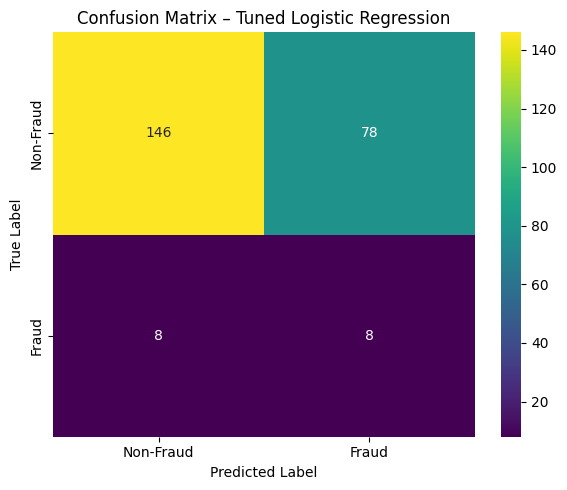

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=["Non-Fraud", "Fraud"],
    yticklabels=["Non-Fraud", "Fraud"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Tuned Logistic Regression")
plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, "logReg_tuned_confusion_matrix.png"),
    dpi=200
)

plt.show()


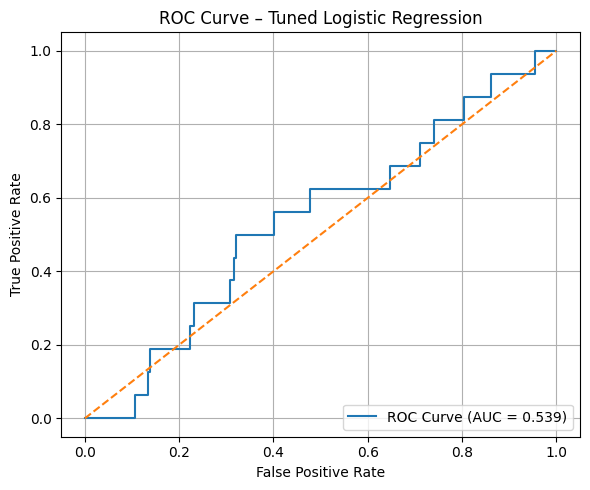

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba_tuned)
roc_auc = roc_auc_score(y_test, y_proba_tuned)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Tuned Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, "logReg_tuned_roc_curve.png"),
    dpi=200
)

plt.show()


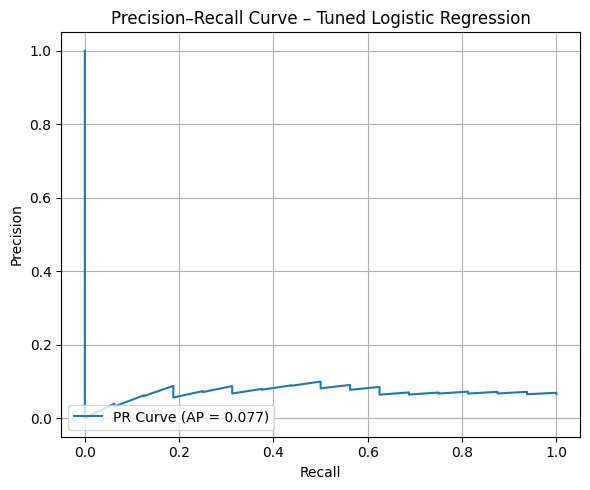

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_tuned)
pr_auc = average_precision_score(y_test, y_proba_tuned)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR Curve (AP = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Tuned Logistic Regression")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, "logReg_tuned_pr_curve.png"),
    dpi=200
)

plt.show()


In [21]:
# Export Logistic Regression coefficients for interpretation
import numpy as np
import pandas as pd
import os

OUTPUT_DIR = '../outputs'
TAB_DIR = os.path.join(OUTPUT_DIR, 'tables')
os.makedirs(TAB_DIR, exist_ok=True)

# Get feature names from the fitted preprocessor
pre = tuned_LR_classifier.named_steps['preprocessor']
num_features = numeric_cols
cat_features = pre.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols).tolist()
feature_names = num_features + cat_features

coef = tuned_LR_classifier.named_steps['classifier'].coef_.ravel()
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coef})
coef_df['abs_coeff'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coeff', ascending=False)

coef_path = os.path.join(TAB_DIR, 'logreg_coefficients.csv')
coef_df.to_csv(coef_path, index=False)
print('Saved:', coef_path)
display(coef_df.head(15))


Saved: ../outputs/tables/logreg_coefficients.csv


,feature,coefficient,abs_coeff
1,device_trust_score,-0.257195,0.257195
32,merchant_category_electronics,-0.188359,0.188359
3,previous_chargeback_count,0.158609,0.158609
9,is_night,-0.157332,0.157332
7,txn_week,0.153402,0.153402
31,channel_web,-0.141078,0.141078
29,channel_mobile_app,0.123151,0.123151
14,customer_std_amount,-0.119295,0.119295
5,txn_hour,0.094768,0.094768
40,slm_anomaly_category_fraud,-0.076091,0.076091
